<a href="https://colab.research.google.com/github/KIRAN-NANGUDE/Projects/blob/main/TASK_(Assignment).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style for better visuals
sns.set(style="whitegrid")

# Load the dataset from the provided URL
url = "https://github.com/YBIFoundation/Pandas/raw/refs/heads/main/ElectroGadget.csv"
df = pd.read_csv(url)

In [27]:
# Display basic information and the first few rows of the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   OrderID         500 non-null    object
 1   Product         500 non-null    object
 2   Category        500 non-null    object
 3   Units Sold      500 non-null    int64 
 4   Price Per Unit  500 non-null    int64 
 5   Revenue         500 non-null    int64 
 6   Region          500 non-null    object
 7   SaleDate        500 non-null    object
dtypes: int64(3), object(5)
memory usage: 31.4+ KB
None


In [28]:
print(df.head())

  OrderID     Product     Category  Units Sold  Price Per Unit  Revenue  \
0  ORD001       Mouse  Accessories           3            1254     3762   
1  ORD002     Charger  Accessories           6             748     4488   
2  ORD003  Headphones  Accessories           4            1034     4136   
3  ORD004      Tablet  Electronics           2             913     1826   
4  ORD005  Smartphone  Electronics           3             869     2607   

  Region    SaleDate  
0   East  10-01-2023  
1  South  04-02-2023  
2  North  17-01-2023  
3  South  15-01-2023  
4   West  20-02-2023  


In [29]:
print(df.columns)

Index(['OrderID', 'Product', 'Category', 'Units Sold', 'Price Per Unit',
       'Revenue', 'Region', 'SaleDate'],
      dtype='object')


In [30]:
# Remove leading/trailing whitespace from all column names
df.columns = df.columns.str.strip()

In [31]:
# Product performance analysis
units_sold = df.groupby('Product')['Units Sold'].sum().sort_values(ascending=False)
print("Top products by units sold:\n", units_sold.head())

Top products by units sold:
 Product
Mouse         348
Laptop        305
Webcam        305
Smartphone    282
Printer       267
Name: Units Sold, dtype: int64


In [32]:
revenue_per_product = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
print("\nTop products by revenue:\n", revenue_per_product.head())


Top products by revenue:
 Product
Smartphone    334987
Laptop        333690
Monitor       333389
Printer       297991
Mouse         283720
Name: Revenue, dtype: int64


In [33]:
avg_price = df.groupby('Product')['Price Per Unit'].mean().sort_values(ascending=False)
print("\nProducts with highest average price:\n", avg_price.head())


Products with highest average price:
 Product
Monitor       1239.000000
Smartphone    1191.720000
Tablet        1170.285714
Printer       1138.218182
Laptop        1085.000000
Name: Price Per Unit, dtype: float64


In [34]:
# Total revenue by region
region_revenue = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
print("Revenue by region:\n", region_revenue)

Revenue by region:
 Region
West     785565
North    663022
South    591146
East     577377
Name: Revenue, dtype: int64


In [35]:
# Total units sold by region
region_units = df.groupby('Region')['Units Sold'].sum().sort_values(ascending=False)
print("\nUnits sold by region:\n", region_units)


Units sold by region:
 Region
West     785
North    701
South    653
East     630
Name: Units Sold, dtype: int64


In [36]:
# Top 5 high-value transactions
high_value_tx = df.sort_values(by='Revenue', ascending=False).head()
print("\nTop 5 high-value transactions:\n", high_value_tx)


Top 5 high-value transactions:
     OrderID     Product     Category  Units Sold  Price Per Unit  Revenue  \
480  ORD481      Tablet  Electronics          10            1984    19840   
305  ORD306  Smartphone  Electronics          10            1982    19820   
117  ORD118     Monitor  Electronics          10            1977    19770   
82   ORD083  Smartphone  Electronics          10            1962    19620   
145  ORD146     Monitor  Electronics          10            1842    18420   

    Region    SaleDate  
480   West  01-01-2023  
305  North  10-01-2023  
117   West  26-02-2023  
82    East  01-03-2023  
145  North  26-02-2023  


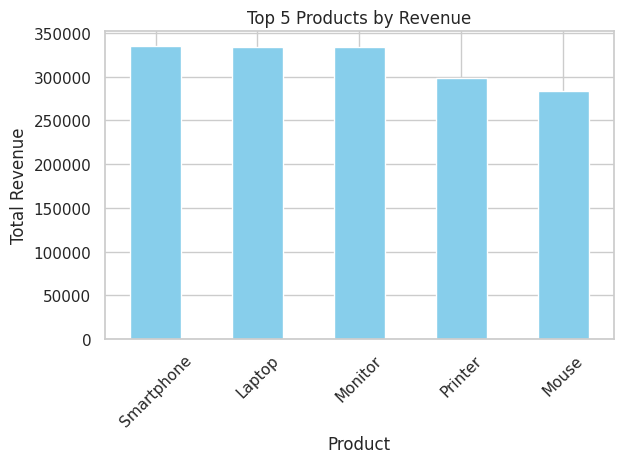

In [37]:
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(5)
top_products.plot(kind='bar', color='skyblue')
plt.title('Top 5 Products by Revenue')
plt.ylabel('Total Revenue')
plt.xlabel('Product')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

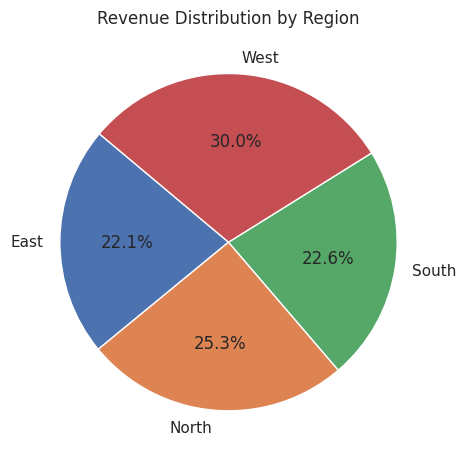

In [38]:
region_revenue = df.groupby('Region')['Revenue'].sum()
region_revenue.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Revenue Distribution by Region')
plt.ylabel('')  # Hide y-label
plt.tight_layout()
plt.show()

/tmp/ipython-input-39-1237194946.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.resample('M', on='SaleDate')['Revenue'].sum()


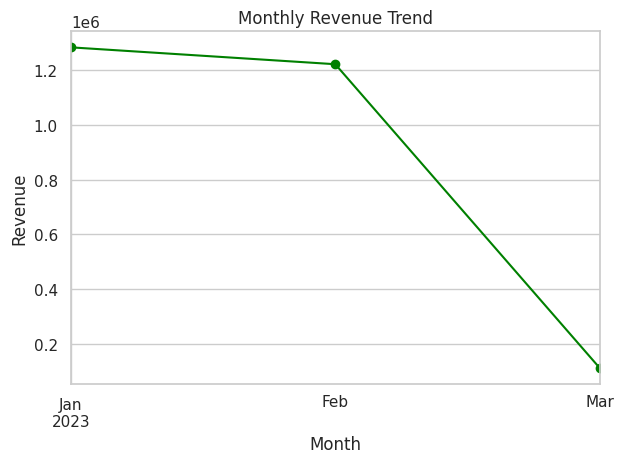

In [39]:
df['SaleDate'] = pd.to_datetime(df['SaleDate'], dayfirst=True)
# Group by month and sum revenue
monthly_revenue = df.resample('M', on='SaleDate')['Revenue'].sum()

# Plot
monthly_revenue.plot(kind='line', marker='o', color='green')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-40-4140679107.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_units = df.resample('M', on='SaleDate')['Units Sold'].sum()


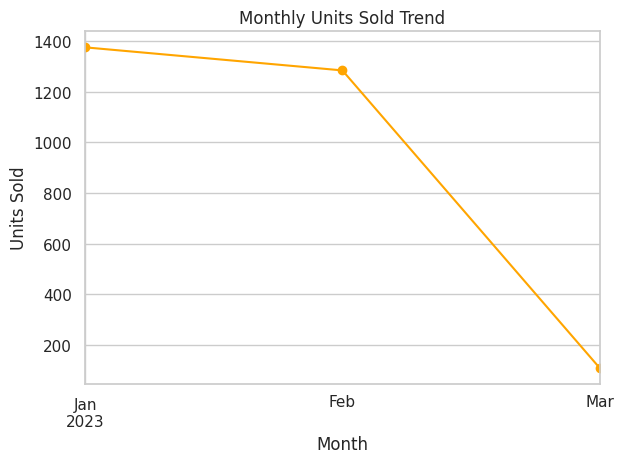

In [40]:
# Group by month and sum units sold
monthly_units = df.resample('M', on='SaleDate')['Units Sold'].sum()

# Plot
monthly_units.plot(kind='line', marker='o', color='orange')
plt.title('Monthly Units Sold Trend')
plt.ylabel('Units Sold')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-41-1085024642.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_summary = df.resample('M', on='SaleDate').agg({


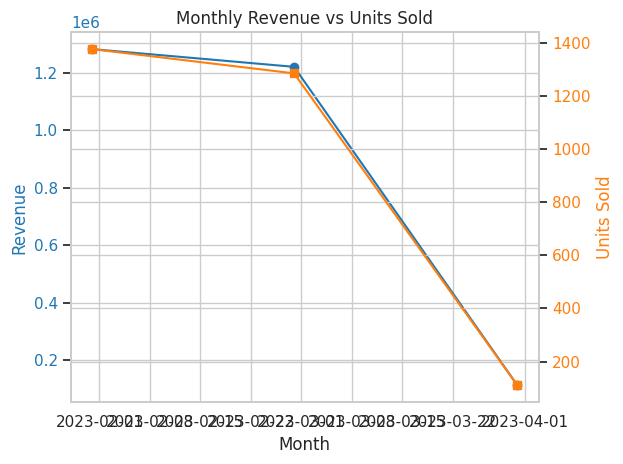

In [41]:
# Create monthly summary
monthly_summary = df.resample('M', on='SaleDate').agg({
    'Revenue': 'sum',
    'Units Sold': 'sum'
})

# Plot with dual y-axis
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue', color=color)
ax1.plot(monthly_summary.index, monthly_summary['Revenue'], color=color, marker='o', label='Revenue')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # Instantiate second axis
color = 'tab:orange'
ax2.set_ylabel('Units Sold', color=color)
ax2.plot(monthly_summary.index, monthly_summary['Units Sold'], color=color, marker='s', label='Units Sold')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Revenue vs Units Sold')
fig.tight_layout()
plt.show()

/tmp/ipython-input-42-3277250922.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_order = df.resample('M', on='SaleDate').apply(lambda x: x['Revenue'].sum() / len(x))


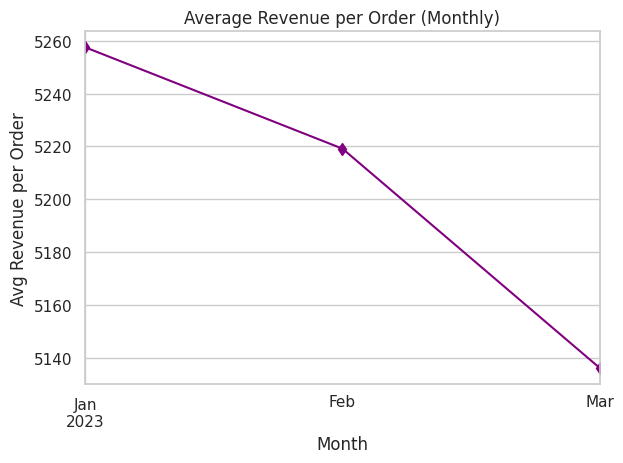

In [42]:
# Calculate average revenue per order per month
monthly_avg_order = df.resample('M', on='SaleDate').apply(lambda x: x['Revenue'].sum() / len(x))
monthly_avg_order.plot(marker='d', color='purple')
plt.title('Average Revenue per Order (Monthly)')
plt.ylabel('Avg Revenue per Order')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
# Convert SaleDate to datetime with dayfirst (if not already done)
df['SaleDate'] = pd.to_datetime(df['SaleDate'], dayfirst=True)

# Group by SaleDate (month) and Category, summing Revenue
monthly_category_revenue = df.groupby([pd.Grouper(key='SaleDate', freq='M'), 'Category'])['Revenue'].sum().unstack()

# Display first few rows to check
print(monthly_category_revenue.head())

Category    Accessories  Electronics
SaleDate                            
2023-01-31       538774       744061
2023-02-28       462997       758283
2023-03-31        42027        70968


/tmp/ipython-input-43-1797411626.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_category_revenue = df.groupby([pd.Grouper(key='SaleDate', freq='M'), 'Category'])['Revenue'].sum().unstack()


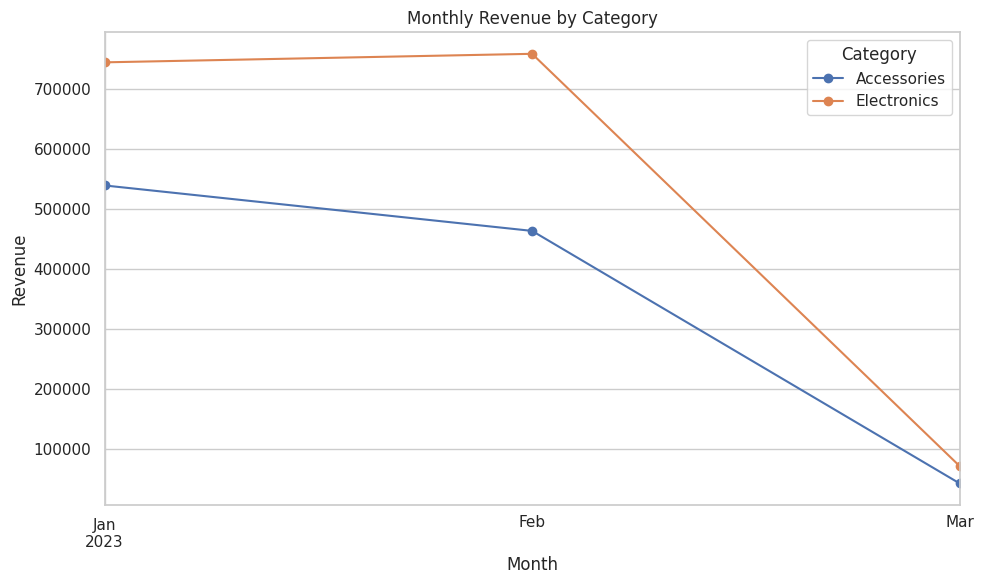

In [44]:
monthly_category_revenue.plot(kind='line', marker='o', figsize=(10,6))
plt.title('Monthly Revenue by Category')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.grid(True)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

/tmp/ipython-input-45-2232069871.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_category_units = df.groupby([pd.Grouper(key='SaleDate', freq='M'), 'Category'])['Units Sold'].sum().unstack()


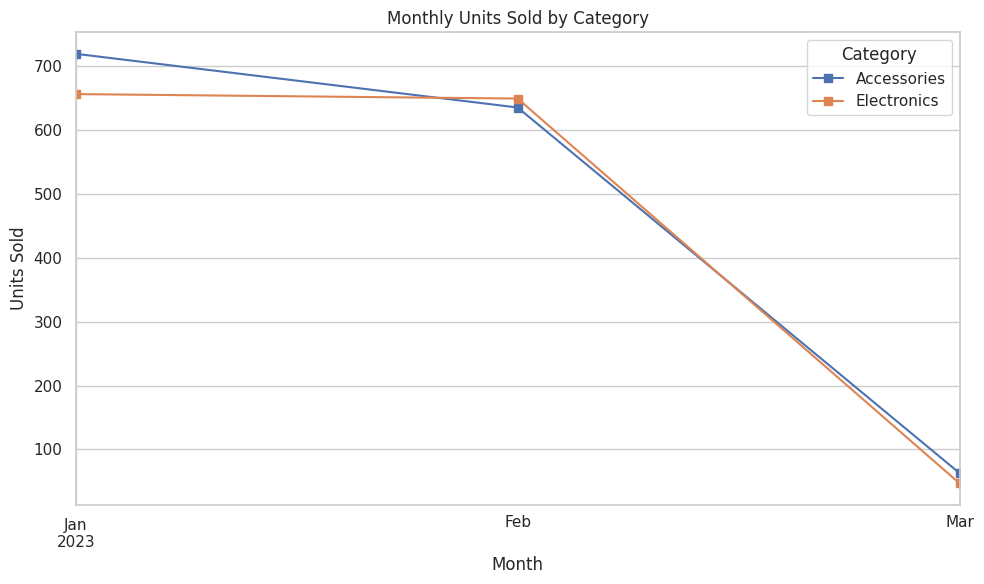

In [45]:
monthly_category_units = df.groupby([pd.Grouper(key='SaleDate', freq='M'), 'Category'])['Units Sold'].sum().unstack()

monthly_category_units.plot(kind='line', marker='s', figsize=(10,6))
plt.title('Monthly Units Sold by Category')
plt.ylabel('Units Sold')
plt.xlabel('Month')
plt.grid(True)
plt.legend(title='Category')
plt.tight_layout()
plt.show()